The data are taken from <b>European Centre for Disease Prevention and Control</b> <br>
https://www.ecdc.europa.eu/en/publications-data/download-historical-data-20-june-2022-weekly-number-new-reported-covid-19-cases

In [1]:
import pandas as pd             #for reading & storing data, pre-processing
import numpy as np              #for numerical computations like log, exp, sqrt etc
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/06-DUQ_hourly.csv")
df.head()

,Datetime,DUQ_MW
0,2005-12-31 01:00:00,1458.0
1,2005-12-31 02:00:00,1377.0
2,2005-12-31 03:00:00,1351.0
3,2005-12-31 04:00:00,1336.0
4,2005-12-31 05:00:00,1356.0


In [3]:
# Preprocessing
df.columns = ["Datetime", "Energy"]
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.set_index("Datetime", inplace=True)

df = df.sort_index()

df.head()

,Energy
Datetime,
2005-01-01 01:00:00,1364.0
2005-01-01 02:00:00,1273.0
2005-01-01 03:00:00,1218.0
2005-01-01 04:00:00,1170.0
2005-01-01 05:00:00,1166.0


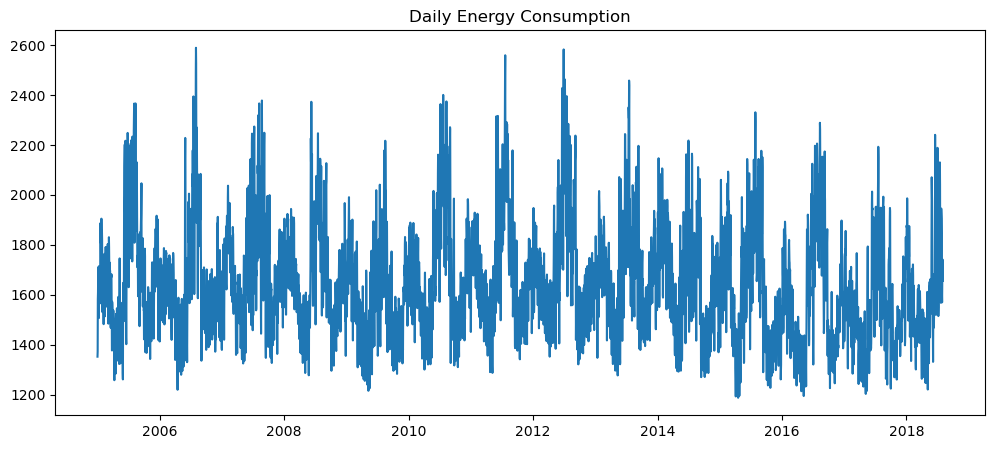

In [4]:
# Resample (convert hourly → daily)
df_daily = df.resample("D").mean()

plt.figure(figsize=(12,5))
plt.plot(df_daily)
plt.title("Daily Energy Consumption")
plt.show()

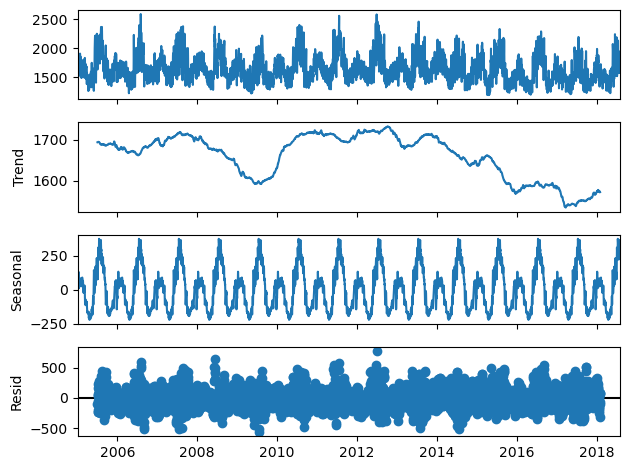

In [5]:
# Decomposition
decomposition = seasonal_decompose(df_daily, model='additive', period=365)

decomposition.plot()
plt.show()

In [6]:
# Stationarity Test
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("Stationary")
    else:
        print("Non-stationary")

adf_test(df_daily["Energy"])

ADF Statistic: -7.335677432853211
p-value: 1.0981941751078254e-10
Stationary


In [8]:
# Train/Test Split (Time-Based)
train_size = int(len(df_daily) * 0.8)

train = df_daily[:train_size]
test = df_daily[train_size:]

## ARIMA Model

In [9]:
model = ARIMA(train["Energy"], order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Energy   No. Observations:                 3970
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -24169.635
Date:                Fri, 27 Mar 2026   AIC                          48349.269
Time:                        20:46:17   BIC                          48380.701
Sample:                    01-01-2005   HQIC                         48360.415
                         - 11-14-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5988      0.031     19.130      0.000       0.537       0.660
ar.L2         -0.2149      0.028     -7.731      0.000      -0.269      -0.160
ma.L1         -0.5169      0.031    -16.706      0.0

## Forecasting with ARIMA model

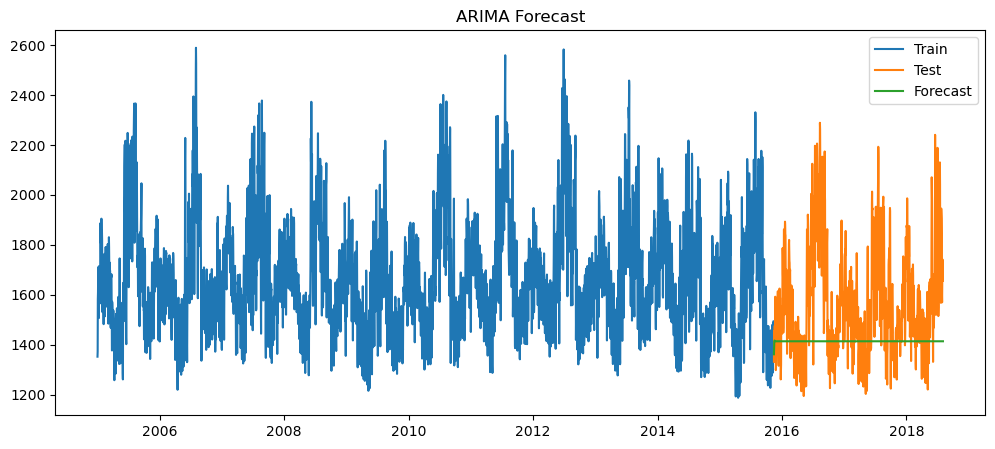

In [10]:
forecast = model_fit.forecast(steps=len(test))

plt.figure(figsize=(12,5))
plt.plot(train.index, train["Energy"], label="Train")
plt.plot(test.index, test["Energy"], label="Test")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.title("ARIMA Forecast")
plt.show()

## Evaluation

In [11]:
mae = mean_absolute_error(test["Energy"], forecast)
rmse = np.sqrt(mean_squared_error(test["Energy"], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 192.92184214043036
RMSE: 267.32380975070566


## Residual Analysis

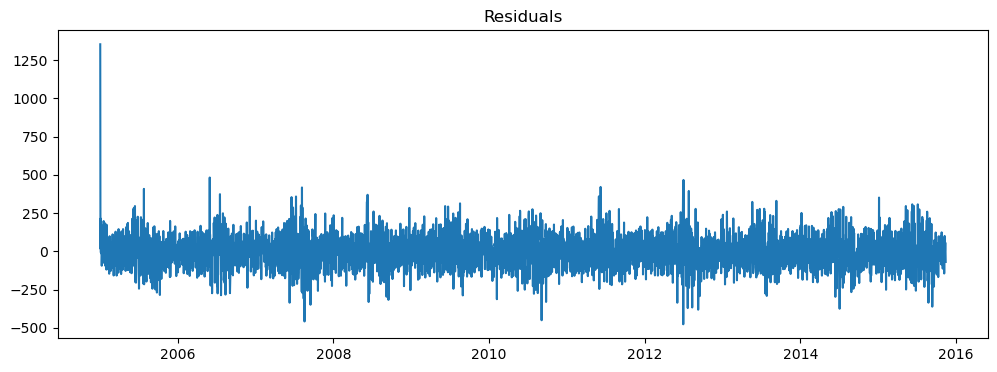

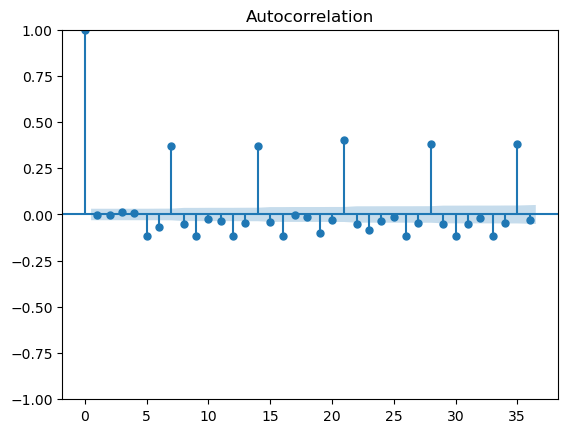

In [12]:
residuals = model_fit.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

plot_acf(residuals)
plt.show()